In [284]:
words = open('names.txt', 'r').read().splitlines()

alphabet = sorted(list(set(''.join(words)+'.')))
stoi = {s: i for i, s in enumerate(alphabet)}

In [391]:
import torch

block_size = 3

def getSamplesForWords(words: list[str]):
	xs, ys = [], []
	for word in words:
		seen = [stoi['.']]*block_size
		for c in word+'.':
			xs.append(seen)
			ys.append(stoi[c])

			seen=seen[1:]
			seen.append(stoi[c])
	return (torch.tensor(xs), torch.tensor(ys))

x_train, y_train = getSamplesForWords(words[:int(len(words)*.8)])
x_dev, y_dev = getSamplesForWords(words[int(len(words)*.8):int(len(words)*.9)])
x_test, y_test = getSamplesForWords(words[int(len(words)*.9):])


In [393]:
import matplotlib.pyplot as plt

g = torch.Generator().manual_seed(5)
embedding_dimensions = 2
hidden_layer_size = 100

# make trainiable embeddings for each letter
embeddings = torch.randn((len(alphabet), 2), generator=g) # 27 x 2
 
weights_1 = torch.randn((block_size * embedding_dimensions, hidden_layer_size), generator=g)
bias_1 = torch.randn(hidden_layer_size, generator=g)

weights_2 = torch.randn((hidden_layer_size, len(alphabet)), generator=g)
bias_2 = torch.randn(len(alphabet), generator=g)

parameters = [embeddings, weights_1, bias_1, weights_2, bias_2]
for p in parameters:
	p.requires_grad = True

sum(p.nelement() for p in parameters)

3481

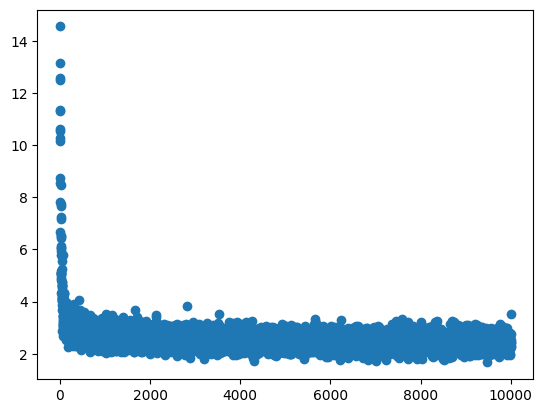

In [394]:
import torch.nn.functional as F
import random

losses = []
for epoch in range(10000):
	n_samples = 32
	indexes = torch.randint(0, x_train.shape[0], (n_samples, ))
	x_sample, y_sample = x_train[indexes], y_train[indexes]

	embedded = embeddings[x_sample].view(-1, embedding_dimensions*block_size) # now nSamples x 6
	hidden = torch.tanh(embedded @ weights_1+bias_1)
	logits = (hidden @ weights_2 + bias_2)
	loss = F.cross_entropy(logits, y_sample) #exp, probs, nll

	for p in parameters:
		p.grad = None
	loss.backward()
	losses.append(loss.detach().numpy())
	for p in parameters:
		if p.grad == None:
			print('NO GRAD!')
			break
		p.data += -0.1 * p.grad

plt.scatter(range(len(losses)), losses)

In [395]:
embedded = embeddings[x_train].view(-1, embedding_dimensions*block_size) # now nSamples x 6
hidden = torch.tanh(embedded @ weights_1+bias_1)
logits = (hidden @ weights_2 + bias_2)
loss = F.cross_entropy(logits, y_train) #exp, probs, nll
loss

tensor(2.4565, grad_fn=<NllLossBackward0>)

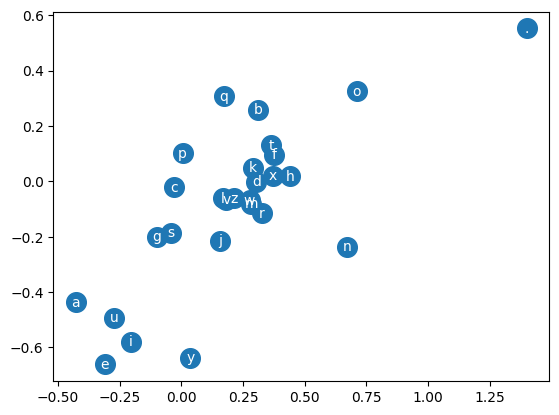

In [396]:
plt.scatter(embeddings[:, 0].detach(), embeddings[:, 1].detach(), s=200)
for i in range(embeddings.shape[0]):
	plt.text(embeddings[i][0].item(), embeddings[i][1].item(), alphabet[i], ha="center", va="center", color="white")

In [426]:
# sample from it

for _ in range(15):
	ix = torch.zeros(3, dtype=torch.long)
	out = []
	while True:
		embedded = embeddings[ix].view(-1, embedding_dimensions*block_size)
		hidden = torch.tanh(embedded@weights_1+bias_1)
		logits = hidden@weights_2+bias_2
		counts = logits.exp()
		probs = counts/counts.sum(1, keepdim=True)
		res = torch.multinomial(probs, 1, replacement=True, generator=g)
		if res == 0:
			break;
		
		out.append(alphabet[int(res.item())])
		ix = ix[1:]
		ix=torch.cat((ix, res[0]), dim=0)
	print("".join(out))

oakin
vrianmerye
salytsijo
rarily
ahmaryamy
danvidahye
soaalouif
suuna
adrafa
vay
hivte
aun
nassyonneelan
tayda
kva
